<!-- reader-content -->

# What happens during a qubit measurement?

A qubit starts in $|+\rangle=(|0\rangle+|1\rangle)/\sqrt{2}$. As we monitor
$\sigma_z$, some trajectories approach a pole quickly; others wander or reverse
direction before settling. Generate these individual histories and the density
of an entire ensemble from the same dispersive-readout model.

[Murch et al. (2013)](https://doi.org/10.1038/nature12539) tracked conditional
superconducting-qubit states and checked them with tomography on repeated
preparations. Here we simulate ideal detection and no intrinsic qubit decay.
The figures illustrate that measurement dynamics; they do not fit the experiment's
finite-efficiency data or perform an experimental tomography validation.

## Set the measurement strength from the resonator

The resonator has a 20 MHz linewidth and a full conditional frequency pull of
$-4$ MHz. Drive halfway between its two conditional resonances, then compare
the steady fields for the qubit in $|0\rangle$ and $|1\rangle$.
Apply a 400 ns square readout pulse to the coupled qubit and resonator, once
from each qubit basis state. The final cavity fields set the measurement rate.

In [1]:
import numpy as np
from quchip import (
    RWA, ChargeDrive, Chip, CrossKerr, Qubit, QuantumSequence, Resonator, Square,
)

amplitude = 0.008                     # charge-drive amplitude, GHz
kappa = 2 * np.pi * 0.020             # resonator linewidth, 1/ns
q = Qubit(freq=5.0, label="q")
r = Resonator(freq=6.0, levels=12, T1=1 / kappa, label="r")
readout = Chip(
    [q, r], couplings=[CrossKerr(q, r, chi=-0.004, label="qr")],
    frame={"q": 5.0, "r": 5.998}, approximation=RWA(),
)

drive = ChargeDrive(r, label="readout")
_ = readout.wire(drive)
sequence = QuantumSequence(readout)
_ = sequence.schedule(
    drive, envelope=Square(duration=400.0, amplitude=amplitude), freq=5.998,
)

branches = sequence.simulate_batch(
    sequence.vary("initial_state", [{"q": 0, "r": 0}, {"q": 1, "r": 0}]),
    tlist=np.arange(401.0), e_ops=readout.e_ops(r=["a", "n"]),
    states="none", progress=False,
)

alpha = np.array([branch.expect(r, 0)[-1] for branch in branches])
nbar = float(branches[1].expect(r, 1)[-1].real)
gamma = float(kappa * abs(alpha[0] - alpha[1]) ** 2 / 2)
print(f"Measurement dephasing: {gamma:.8f} /ns; steady photons: {nbar:.6f}")

Measurement dephasing: 0.00148714 /ns; steady photons: 0.153846


We use the steady-field reduction
$\Gamma_m=\kappa|\alpha_0-\alpha_1|^2/2$, represented by
$L=\sqrt{\Gamma_m/2}\,\sigma_z$. Then
$\mathcal D[L]\rho=(\Gamma_m/2)(\sigma_z\rho\sigma_z-\rho)$ and the
unconditional coherence decays as $e^{-\Gamma_m t}$.
Here `gamma` means $\Gamma_m$, in $\mathrm{ns}^{-1}$.
The cavity settles on a scale $2/\kappa\approx16$ ns, much shorter than
$1/\Gamma_m$. The reduced model starts with the field already settled and tracks
out the deterministic Stark rotation. It omits the initial cavity transient.

## Monitor the qubit

Give the qubit its transition frequency and set the chip to its rotating frame.
This removes free precession, leaving measurement backaction. `T1=None` omits
relaxation; `T2=1/gamma` represents the measurement-induced dephasing, with no
additional unobserved dephasing. The effective frequency includes the steady Stark shift.

The standard channel is $L=\sqrt{2\Gamma_m}\,n$, with
$n=(I-\sigma_z)/2$. Its dissipator is the same as the Pauli form above.
A homodyne phase of $\pi$ matches the Pauli trajectory's noise-sign convention;
the identity offset only changes the record's baseline.
We prepare the bare $|+\rangle$ because the plotted axes use that Pauli basis.

In [2]:
from quchip import with_monitoring

meter = Qubit(freq=5.0, T1=None, T2=1 / gamma, label="q")
chip = Chip([meter], backend="qutip", frame="rotating")

plus = (chip.bare_state({meter: 0}) + chip.bare_state({meter: 1})) / np.sqrt(2)
t = np.arange(0.0, 1000.0 + 5.0, 5.0)  # saved samples in ns
shots, seed = 3000, 11

problem = QuantumSequence(chip).build_problem(
    t, initial_state=plus, solver="smesolve", states="none",
    e_ops=chip.e_ops(q=[meter.sigma_x, meter.sigma_y, meter.sigma_z]),
    run_args={"ntraj": shots, "seeds": seed},
    options={"method": "platen", "dt": 0.05, "map": "loky", "num_cpus": 4,
             "keep_runs_results": True, "progress_bar": ""},
)

channel = problem.engine_result.slh.channels[0]
result = chip.solve(with_monitoring(problem, {channel.key: 1.0}, phases={channel.key: np.pi}))

bloch = np.empty((shots, len(t), 3))
for i in range(shots):
    trajectory = result.run(i)
    bloch[i] = np.column_stack([trajectory.expect(meter, k).real for k in range(3)])

np.savez_compressed(
    "paths-plus-z.npz", bloch=bloch.astype(np.float32), t=t,
    gamma=gamma, nbar=nbar, amp=amplitude,
)

print(f"Bloch data: {bloch.shape}; final |z| > 0.95: {np.mean(abs(bloch[:, -1, 2]) > 0.95):.3f}")

Bloch data: (3000, 201, 3); final |z| > 0.95: 0.748


`paths-plus-z.npz` saves the array with axes `(shot, saved time, x/y/z)`. States are not retained because
these three observables contain the qubit information used here. `dt=0.05` ns
sets the native integration step; the 5 ns save interval only sets the plot
sampling. QuTiP runs the seeded trajectories across four worker processes; the
loop above only extracts their observables.
The 3,000-shot ensemble includes the four histories shown below.

## Compare individual histories

Each video below selects five paths ending near each pole. The selections expose
different histories within the same ensemble; they are neither disjoint classes
nor estimates of their prevalence. “Early return” means a path approached its
eventual pole, then moved away. “Reversal” means it first approached the opposite
pole. No external kick or relaxation is applied: a state near an eigenstate can
reverse, while an exact $\sigma_z$ eigenstate is stationary under this measurement.

<details>
<summary>Select and plot the histories</summary>

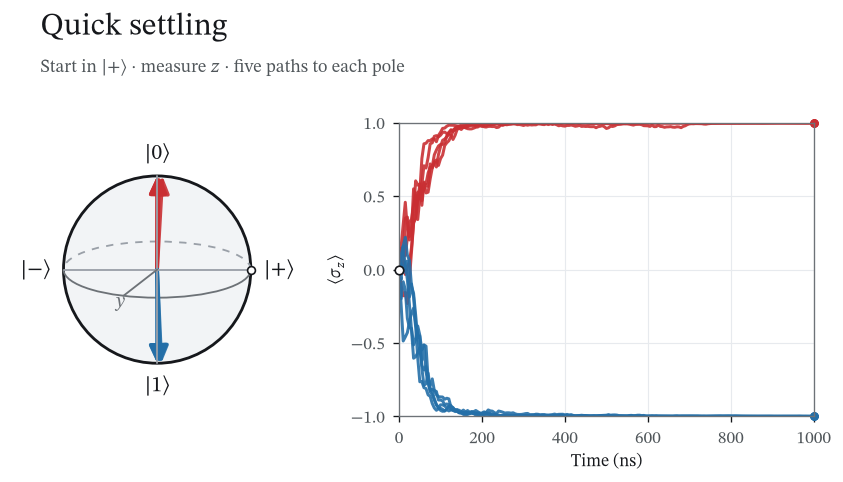

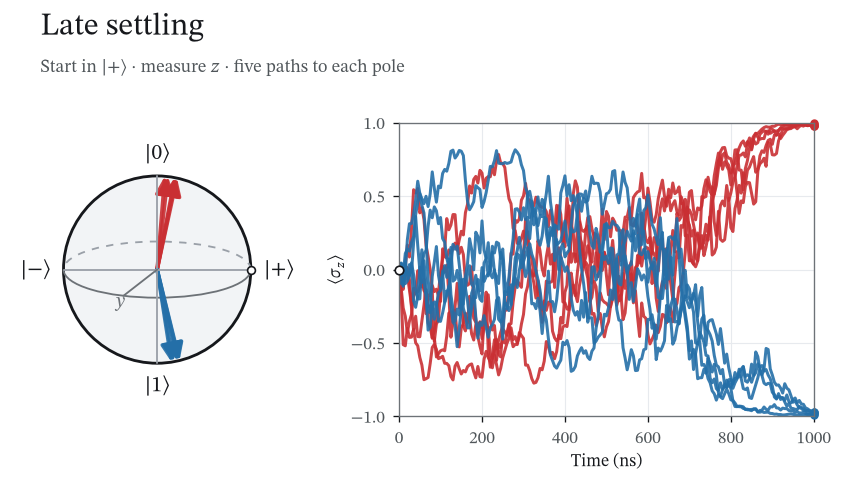

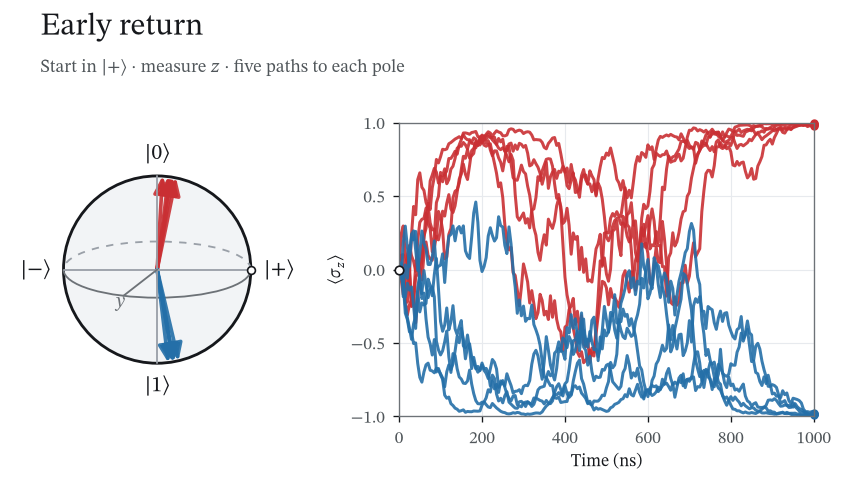

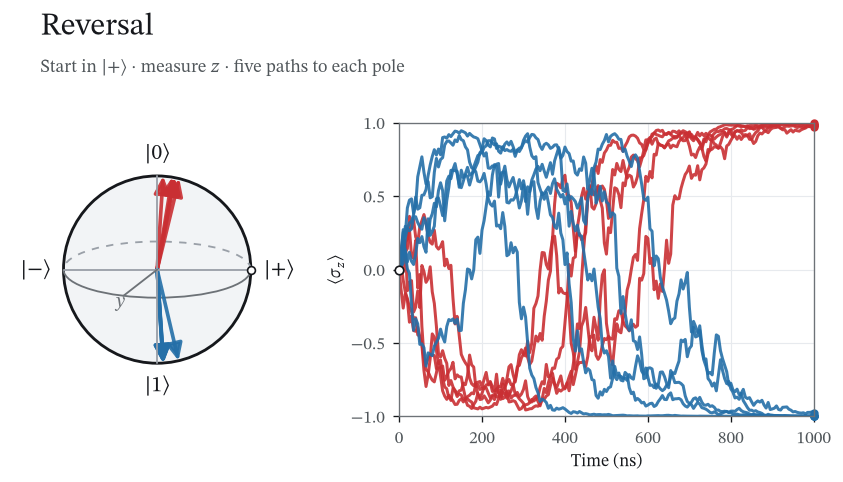

In [3]:
import shutil
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch

plt.style.use("../docs/_static/quchip.mplstyle")
plt.rcParams["text.usetex"] = bool(shutil.which("latex"))

z = bloch[:, :, 2]
selected = {}
for kind in ("Quick settling", "Late settling", "Early return", "Reversal"):
    selected[kind] = []

    for sign in (1, -1):
        toward = sign * z
        candidates = np.flatnonzero(toward[:, -1] > 0.97)

        if kind == "Quick settling":
            last_outside = np.max(np.where(toward <= 0.95, np.arange(len(t)), -1), axis=1)
            score = -t[np.minimum(last_outside + 1, len(t) - 1)]
        elif kind == "Reversal":
            candidates = candidates[toward[candidates].min(axis=1) < -0.9]
            score = (-toward).max(axis=1)
        else:
            after = t >= (400.0 if kind == "Early return" else 250.0)
            if kind == "Early return":
                early = np.any(toward[:, t <= 400.0] > 0.9, axis=1)
                returned = toward[:, after].min(axis=1) < 0.5
                candidates = candidates[early[candidates] & returned[candidates]]
            score = abs(np.diff(toward[:, after], axis=1)).sum(axis=1) + 4 * (1 - toward[:, after]).mean(axis=1)

        if len(candidates) < 5:
            raise ValueError(f"Too few {kind.lower()} paths toward pole {sign}; increase shots.")

        selected[kind].extend(candidates[np.argsort(-score[candidates])[:5]])

history_figures = {}
for kind, indices in selected.items():
    name = kind.lower().replace(" ", "_")
    fig = plt.figure(figsize=(7.2, 4.45))
    fig.text(0.06, 0.91, kind, fontsize=19)
    fig.text(0.06, 0.84, r"Start in $|+\rangle$ · measure $z$ · five paths to each pole",
             fontsize=11, color="#50565A")

    sphere = fig.add_axes((0.027, 0.198, 0.336, 0.544))
    sphere.set(xlim=(-1.55, 1.55), ylim=(-1.55, 1.55), aspect="equal")
    sphere.axis("off")
    sphere.add_patch(Circle((0, 0), 1, facecolor="#F2F4F6", edgecolor="#16181C", lw=1.7))
    sphere.add_patch(Arc((0, 0), 2, 0.6, theta1=0, theta2=180,
                         color="#9AA0A8", lw=1.1, linestyle=(0, (4, 4))))
    sphere.add_patch(Arc((0, 0), 2, 0.6, theta1=180, theta2=360, color="#6D7277", lw=1.1))
    sphere.plot([-1, 1], [0, 0], color="#9AA0A8", lw=1.1)
    sphere.plot([0, 0], [-1, 1], color="#9AA0A8", lw=1.1)
    sphere.plot([0, -0.36], [0, -0.28], color="#6D7277", lw=1.1)
    sphere.text(-0.45, -0.4, "$y$", color="#6D7277", fontsize=12)

    for x, y, label in ((0, 1.24, r"$|0\rangle$"), (0, -1.24, r"$|1\rangle$"),
                         (1.3, 0, r"$|+\rangle$"), (-1.3, 0, r"$|-\rangle$")):
        sphere.text(x, y, label, ha="center", va="center", fontsize=13)
    sphere.scatter([1], [0], s=22, facecolor="white", edgecolor="#16181C", zorder=20)

    trace = fig.add_axes((0.475, 0.195, 0.48, 0.55))
    trace.set(xlim=(0, t[-1]), ylim=(-1, 1), yticks=(-1, -0.5, 0, 0.5, 1),
              xticks=np.arange(0, 1001, 200), xlabel="Time (ns)", ylabel=r"$\langle\sigma_z\rangle$")
    trace.grid(True)
    for spine in trace.spines.values():
        spine.set_visible(True)
        spine.set_color("#6D7277")

    artists = []
    for i in indices:
        color = "#C92F33" if z[i, -1] > 0 else "#246FA8"
        arrow = FancyArrowPatch((0, 0), bloch[i, -1, [0, 2]],
                                arrowstyle="-|>,head_length=8.4,head_width=3.9",
                                mutation_scale=1, lw=2.2, color=color, alpha=0.9,
                                shrinkA=0, shrinkB=0, capstyle="round", joinstyle="round")
        sphere.add_patch(arrow)
        line, = trace.plot(t, z[i], color=color, lw=1.8, alpha=0.9)
        dot, = trace.plot(t[-1], z[i, -1], "o", color=color, ms=4, clip_on=False)
        artists.append((i, arrow, line, dot))

    trace.scatter([0], [0], s=26, facecolor="white", edgecolor="#16181C", zorder=20, clip_on=False)
    cursor = trace.axvline(t[-1], color="#9AA0A8", lw=1.1, ls=(0, (4, 4)), visible=False)
    history_figures[name] = (fig, artists, cursor)
    fig.savefig(f"../docs/images/measurement_{name}.svg")
    plt.show()

</details>

<video controls playsinline preload="none" style="width:100%;height:auto;background:#fff"
       poster="../_images/measurement_quick_settling.svg" aria-label="Quick settling: Bloch vectors and trajectories">
  <source src="../_static/measurement_quick_settling.mp4" type="video/mp4">
  <a href="../_static/measurement_quick_settling.mp4">Play quick settling</a>.
</video>

<video controls playsinline preload="none" style="width:100%;height:auto;background:#fff"
       poster="../_images/measurement_late_settling.svg" aria-label="Late settling: Bloch vectors and trajectories">
  <source src="../_static/measurement_late_settling.mp4" type="video/mp4">
  <a href="../_static/measurement_late_settling.mp4">Play late settling</a>.
</video>

<video controls playsinline preload="none" style="width:100%;height:auto;background:#fff"
       poster="../_images/measurement_early_return.svg" aria-label="Early return: Bloch vectors and trajectories">
  <source src="../_static/measurement_early_return.mp4" type="video/mp4">
  <a href="../_static/measurement_early_return.mp4">Play early return</a>.
</video>

<video controls playsinline preload="none" style="width:100%;height:auto;background:#fff"
       poster="../_images/measurement_reversal.svg" aria-label="Reversal: Bloch vectors and trajectories">
  <source src="../_static/measurement_reversal.mp4" type="video/mp4">
  <a href="../_static/measurement_reversal.mp4">Play reversal</a>.
</video>

All paths start at $+x$. Red and blue indicate the final pole, including before
the outcome becomes apparent. The Bloch vectors and moving dots follow the
current time while each trace keeps its history.

<details>
<summary>Final frames and PDFs</summary>

```{figure} ../images/measurement_quick_settling.svg
:alt: Quick settling: ten conditional qubit trajectories with their final Bloch vectors.

Quick settling. [PDF](../images/measurement_quick_settling.pdf)
```

```{figure} ../images/measurement_late_settling.svg
:alt: Late settling: ten conditional qubit trajectories with their final Bloch vectors.

Late settling. [PDF](../images/measurement_late_settling.pdf)
```

```{figure} ../images/measurement_early_return.svg
:alt: Early return: ten conditional qubit trajectories with their final Bloch vectors.

Early return. [PDF](../images/measurement_early_return.pdf)
```

```{figure} ../images/measurement_reversal.svg
:alt: Reversal: ten conditional qubit trajectories with their final Bloch vectors.

Reversal. [PDF](../images/measurement_reversal.pdf)
```

</details>

## Map the ensemble and a selected endpoint

[Weber et al. (2014)](https://doi.org/10.1038/nature13559) studied density maps
and most-likely paths with both initial and final states specified. For their
no-drive case and ideal efficiency, the analytic path from $z(0)=0$ to $z(T)=z_f$
is $z_\mathrm{opt}(t)=\tanh[(t/T)\operatorname{arctanh}(z_f)]$ and
$x_\mathrm{opt}(t)=\sqrt{1-z_\mathrm{opt}(t)^2}$.
The paper's measurement time is $\tau=1/(2\Gamma_m)$ in our convention.

Select $z(1000\,\mathrm{ns})=0.8\pm0.03$ from the already generated ensemble.
The dashed curve is the analytic most-likely path. The solid curve is the mean
of the selected paths, a different statistic. No optimizer or additional solve
is needed for this no-drive result.

In [4]:
target, window = 0.8, 0.03
conditioned = abs(z[:, -1] - target) < window
optimal = np.tanh(t / t[-1] * np.arctanh(target))
print(f"Endpoint-selected shots: {conditioned.sum()} of {shots}")

Endpoint-selected shots: 33 of 3000


<details>
<summary>Plot the two density maps</summary>

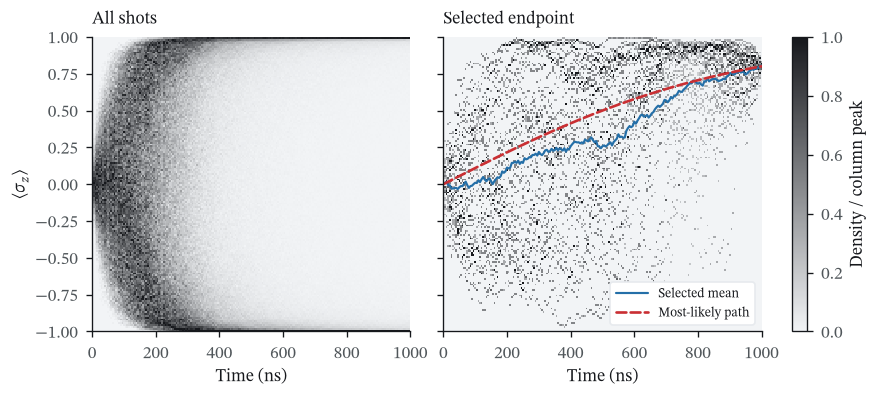

In [5]:
from matplotlib.colors import LinearSegmentedColormap

edges = np.linspace(-1, 1, 161)
cmap = LinearSegmentedColormap.from_list("measurement", ["#F2F4F6", "#16181C"])
density_images = []

density_fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), sharey=True, layout="constrained")
for axis, paths, title in zip(axes, (z, z[conditioned]), ("All shots", "Selected endpoint")):
    counts = np.stack([np.histogram(paths[:, j], bins=edges)[0] for j in range(len(t))], axis=1)
    density = counts.astype(float)
    density /= density.max(axis=0, keepdims=True)
    image = axis.imshow(density, origin="lower", aspect="auto", cmap=cmap, vmin=0, vmax=1,
                        extent=(-2.5, t[-1] + 2.5, -1, 1), interpolation="nearest")
    density_images.append((image, density))

    axis.set(title=title, xlabel="Time (ns)", xlim=(0, t[-1]), ylim=(-1, 1))
    axis.grid(False)

axes[0].set_ylabel(r"$\langle\sigma_z\rangle$")
selected_mean = z[conditioned].mean(axis=0)
mean_line, = axes[1].plot(t, selected_mean, color="#246FA8", lw=1.3, label="Selected mean")
optimal_line, = axes[1].plot(t, optimal, color="#C92F33", ls="--", lw=1.6, label="Most-likely path")
axes[1].legend(loc="lower right", fontsize=8, frameon=True, framealpha=1,
               facecolor="#FFFFFF", edgecolor="#E7EAEE")
density_fig.colorbar(image, ax=axes, label="Density / column peak", fraction=0.035, pad=0.02)
density_fig.savefig("../docs/images/measurement_density.svg")
plt.show()

</details>

<video controls playsinline preload="none" style="width:100%;height:auto;background:#fff"
       poster="../_images/measurement_density.svg"
       aria-label="Evolving trajectory density maps and a most-likely path">
  <source src="../_static/measurement_density.mp4" type="video/mp4">
  <a href="../_static/measurement_density.mp4">Play the animation</a>.
</video>

The 160 bins show raw counts with no smoothing or interpolation. Each time
column is divided by its own maximum to show where paths concentrate. Shades cannot compare absolute probabilities between
columns or panels. The endpoint window gives a finite subensemble around the
analytic path's exact boundary condition.

<details>
<summary>Final frame and PDF</summary>

```{figure} ../images/measurement_density.svg
:alt: The density of all simulated trajectories splits toward the poles; an endpoint-selected density is compared with its mean and analytic most-likely path.

Final frame. [PDF](../images/measurement_density.pdf)
```

</details>

<details>
<summary>Animate the same figures (requires FFmpeg)</summary>

In [6]:
from matplotlib.animation import FFMpegWriter
from IPython.display import Video, display

frames = np.r_[np.linspace(0, len(t) - 1, 240).astype(int), np.full(45, len(t) - 1)]
writer_options = {"fps": 30, "codec": "h264",
                  "extra_args": ["-crf", "18", "-pix_fmt", "yuv420p", "-movflags", "+faststart"]}

# Eight seconds of motion followed by a 1.5-second hold, as in the readout clips.
for name, (fig, artists, cursor) in history_figures.items():
    writer = FFMpegWriter(**writer_options)
    with writer.saving(fig, f"../docs/_static/measurement_{name}.mp4", dpi=200):
        for j in frames:
            for i, arrow, line, dot in artists:
                arrow.set_positions((0, 0), bloch[i, j, [0, 2]])
                line.set_data(t[:j + 1], z[i, :j + 1])
                dot.set_data([t[j]], [z[i, j]])
            cursor.set_xdata([t[j], t[j]])
            cursor.set_visible(j < len(t) - 1)
            writer.grab_frame(facecolor="white")

writer = FFMpegWriter(**writer_options)
with writer.saving(density_fig, "../docs/_static/measurement_density.mp4", dpi=200):
    for j in frames:
        for image, density in density_images:
            revealed = density.copy()
            revealed[:, j + 1:] = np.nan
            image.set_data(revealed)
        mean_line.set_data(t[:j + 1], selected_mean[:j + 1])
        optimal_line.set_data(t[:j + 1], optimal[:j + 1])
        writer.grab_frame(facecolor="white")

for name in (*history_figures, "density"):
    display(Video(f"../docs/_static/measurement_{name}.mp4", embed=False))

</details>

## Check the ensemble

Discarding the measurement record gives $\langle x\rangle=e^{-\Gamma_m t}$
and $\langle z\rangle=0$. The final excited and ground populations average to
one half. For observables bounded by $[-1,1]$, $1/\sqrt{N}$ bounds the standard
error at any one time. Report the largest discrepancy alongside that scale;
refine the integration timestep when studying finer trajectory features.

In [7]:
mean = bloch.mean(axis=0)
print(f"Max ensemble errors: x={abs(mean[:, 0] - np.exp(-gamma * t)).max():.4f}, "
      f"z={abs(mean[:, 2]).max():.4f}; single-time error bound={1 / np.sqrt(shots):.4f}")
print(f"Max Bloch-radius error: {abs(np.linalg.norm(bloch, axis=-1) - 1).max():.2e}")

Max ensemble errors: x=0.0061, z=0.0171; single-time error bound=0.0183
Max Bloch-radius error: 6.03e-04


`paths-plus-z.npz` contains the `(shot, time, 3)` Bloch array and the time,
measurement-rate, photon-number and drive-amplitude values. The fixed seed and
native method reproduce the ensemble within the same QuTiP version; parallel
workers may return the shots in a different order.

For the experimental reconstruction and the path equations, see
[Murch et al., Nature 502, 211 (2013)](https://arxiv.org/abs/1305.7270) and
[Weber et al., Nature 511, 570 (2014)](https://arxiv.org/abs/1403.4992).